# **Bubble Plots**

In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.

## Objectives

In this lab, you will perform the following:

-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.

#### Setup: Working with the Database
**Install and import the needed libraries**

In [2]:
#!pip install pandas 
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**

To start, download and load the dataset into a `pandas` DataFrame.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load dataset into DataFrame
df = pd.read_csv(file_url)

# Display first 5 rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots

#### 1. Bubble Plot for Age vs. Frequency of Participation

- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).

In [4]:
# Select required columns

bubble_df = df[
    ['Age', 'SOPartFreq', 'JobSat']
].dropna()

# Display first few rows
print(bubble_df.head())

                Age                           SOPartFreq  JobSat
10  35-44 years old  Less than once per month or monthly     8.0
12  35-44 years old                 A few times per week     8.0
15  45-54 years old      A few times per month or weekly     5.0
18  25-34 years old                 A few times per week    10.0
20  25-34 years old  Less than once per month or monthly     6.0


In [5]:
# Convert Age categories into approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

bubble_df['Age_numeric'] = (
    bubble_df['Age']
    .map(age_mapping)
)

In [6]:
# Convert participation frequency into numeric scale

freq_mapping = {
    'Daily or almost daily': 5,
    'A few times per week': 4,
    'A few times per month or weekly': 3,
    'Less than once per month or monthly': 2,
    'Less than monthly or never': 1
}

bubble_df['SOPartFreq_numeric'] = (
    bubble_df['SOPartFreq']
    .map(freq_mapping)
)

In [7]:
# Convert JobSat to numeric

bubble_df['JobSat'] = pd.to_numeric(
    bubble_df['JobSat'],
    errors='coerce'
)

# Remove missing values
bubble_df = bubble_df.dropna()

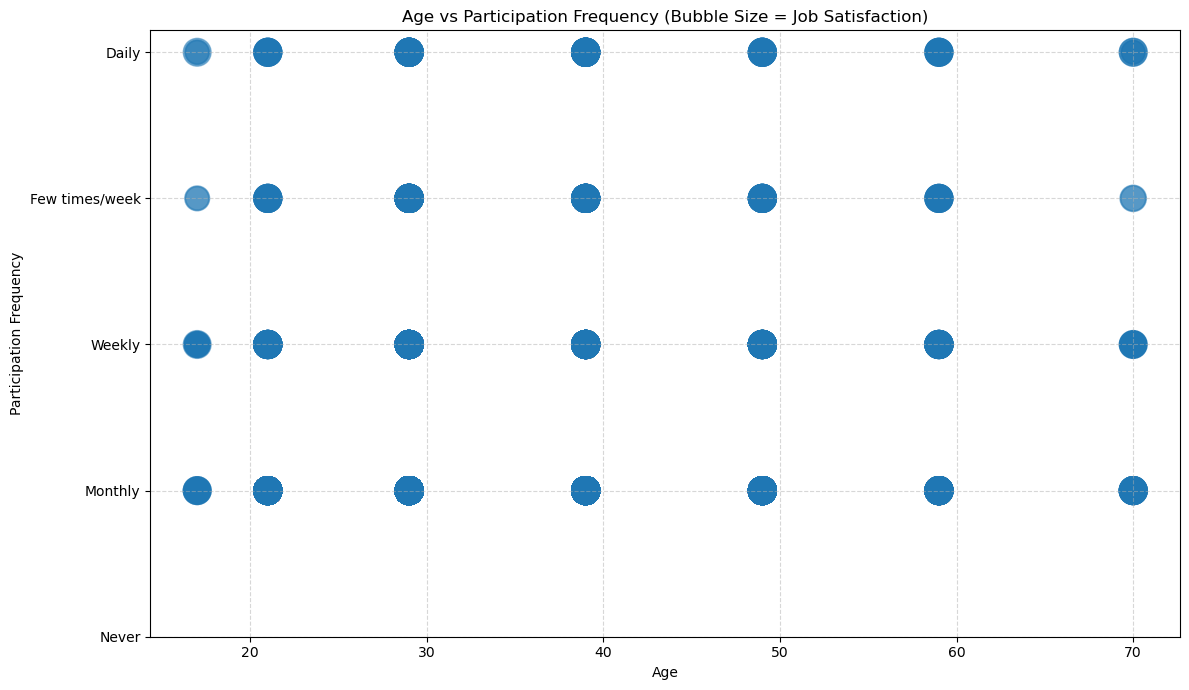

In [8]:
# Create bubble plot

plt.figure(figsize=(12,7))

plt.scatter(
    bubble_df['Age_numeric'],
    bubble_df['SOPartFreq_numeric'],
    s=bubble_df['JobSat'] * 40,   # Bubble size based on Job Satisfaction
    alpha=0.5
)

plt.title('Age vs Participation Frequency (Bubble Size = Job Satisfaction)')
plt.xlabel('Age')
plt.ylabel('Participation Frequency')

# Custom y-axis labels
plt.yticks(
    [1,2,3,4,5],
    [
        'Never',
        'Monthly',
        'Weekly',
        'Few times/week',
        'Daily'
    ]
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction

- Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.

In [9]:
# Select required columns

bubble_df = df[
    ['ConvertedCompYearly', 'JobSat', 'Age']
].dropna()

# Display first few rows
print(bubble_df.head())

     ConvertedCompYearly  JobSat              Age
72                7322.0    10.0  18-24 years old
379              91295.0    10.0  35-44 years old
389             110000.0    10.0  25-34 years old
392             161044.0     7.0  35-44 years old
398             195000.0     5.0  45-54 years old


In [10]:
# Convert numeric columns

bubble_df['ConvertedCompYearly'] = pd.to_numeric(
    bubble_df['ConvertedCompYearly'],
    errors='coerce'
)

bubble_df['JobSat'] = pd.to_numeric(
    bubble_df['JobSat'],
    errors='coerce'
)

In [11]:
# Convert Age categories into approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

bubble_df['Age_numeric'] = (
    bubble_df['Age']
    .map(age_mapping)
)

In [12]:
# Remove missing values

bubble_df = bubble_df.dropna()

In [13]:
# Remove extreme compensation outliers for better visualization

upper_limit = bubble_df['ConvertedCompYearly'].quantile(0.99)

bubble_df = bubble_df[
    bubble_df['ConvertedCompYearly'] <= upper_limit
]

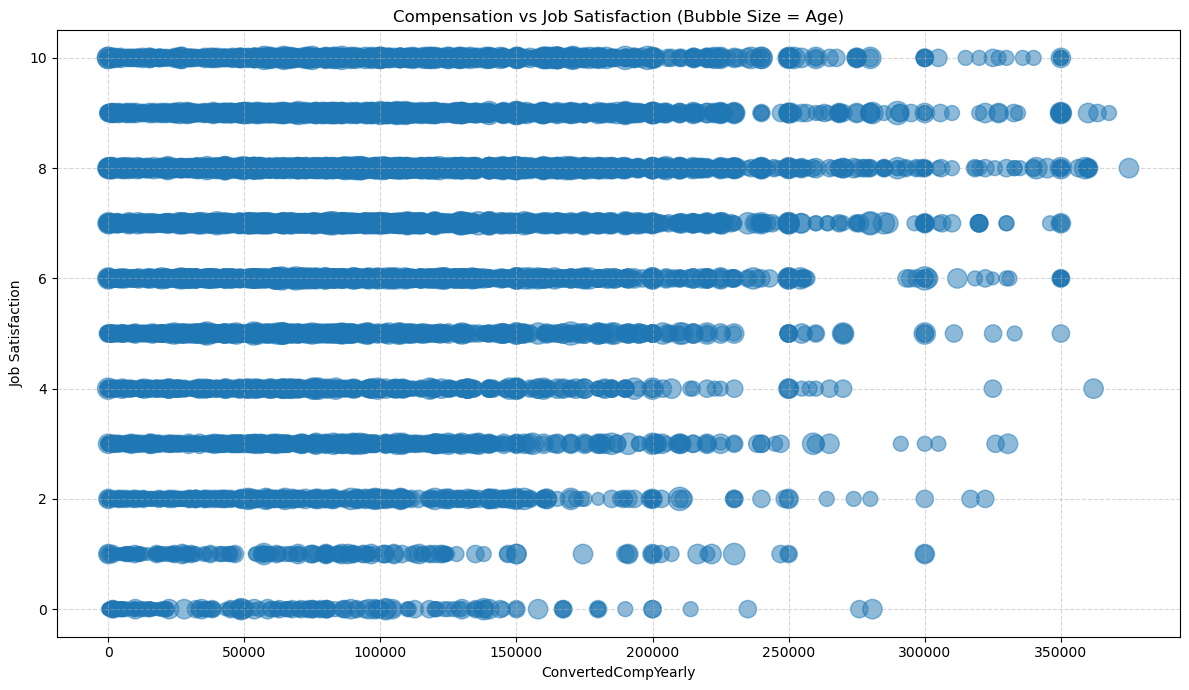

In [14]:
# Create bubble plot

plt.figure(figsize=(12,7))

plt.scatter(
    bubble_df['ConvertedCompYearly'],
    bubble_df['JobSat'],
    s=bubble_df['Age_numeric'] * 4,   # Bubble size based on age
    alpha=0.5
)

plt.title('Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('ConvertedCompYearly')
plt.ylabel('Job Satisfaction')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots

#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.

In [15]:
# Select required columns

lang_df = df[
    ['Age', 'LanguageHaveWorkedWith']
].dropna()

# Display first few rows
print(lang_df.head())

                  Age                             LanguageHaveWorkedWith
1     35-44 years old  Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2     45-54 years old                                                 C#
3     18-24 years old  C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...
4     18-24 years old            C++;HTML/CSS;JavaScript;Lua;Python;Rust
5  Under 18 years old  Bash/Shell (all shells);HTML/CSS;Java;JavaScri...


In [16]:
# Convert Age categories into approximate numeric values

age_mapping = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

lang_df['Age_Group'] = (
    lang_df['Age']
    .map(age_mapping)
)

In [17]:
# Split multiple languages into separate rows

lang_exploded = lang_df.assign(
    LanguageHaveWorkedWith=
    lang_df['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')

In [18]:
# Find top 10 programming languages

top_languages = (
    lang_exploded['LanguageHaveWorkedWith']
    .value_counts()
    .head(10)
    .index
)

print(top_languages)

Index(['JavaScript', 'HTML/CSS', 'Python', 'SQL', 'TypeScript',
       'Bash/Shell (all shells)', 'Java', 'C#', 'C++', 'C'],
      dtype='object', name='LanguageHaveWorkedWith')


In [19]:
# Filter top languages

filtered_df = lang_exploded[
    lang_exploded['LanguageHaveWorkedWith'].isin(top_languages)
].copy()

In [20]:
# Count language frequency by age group

language_counts = (
    filtered_df
    .groupby(['Age_Group', 'LanguageHaveWorkedWith'])
    .size()
    .reset_index(name='Frequency')
)

print(language_counts.head())

  Age_Group   LanguageHaveWorkedWith  Frequency
0     18-24  Bash/Shell (all shells)       4069
1     18-24                        C       4309
2     18-24                       C#       3442
3     18-24                      C++       4543
4     18-24                 HTML/CSS       7724


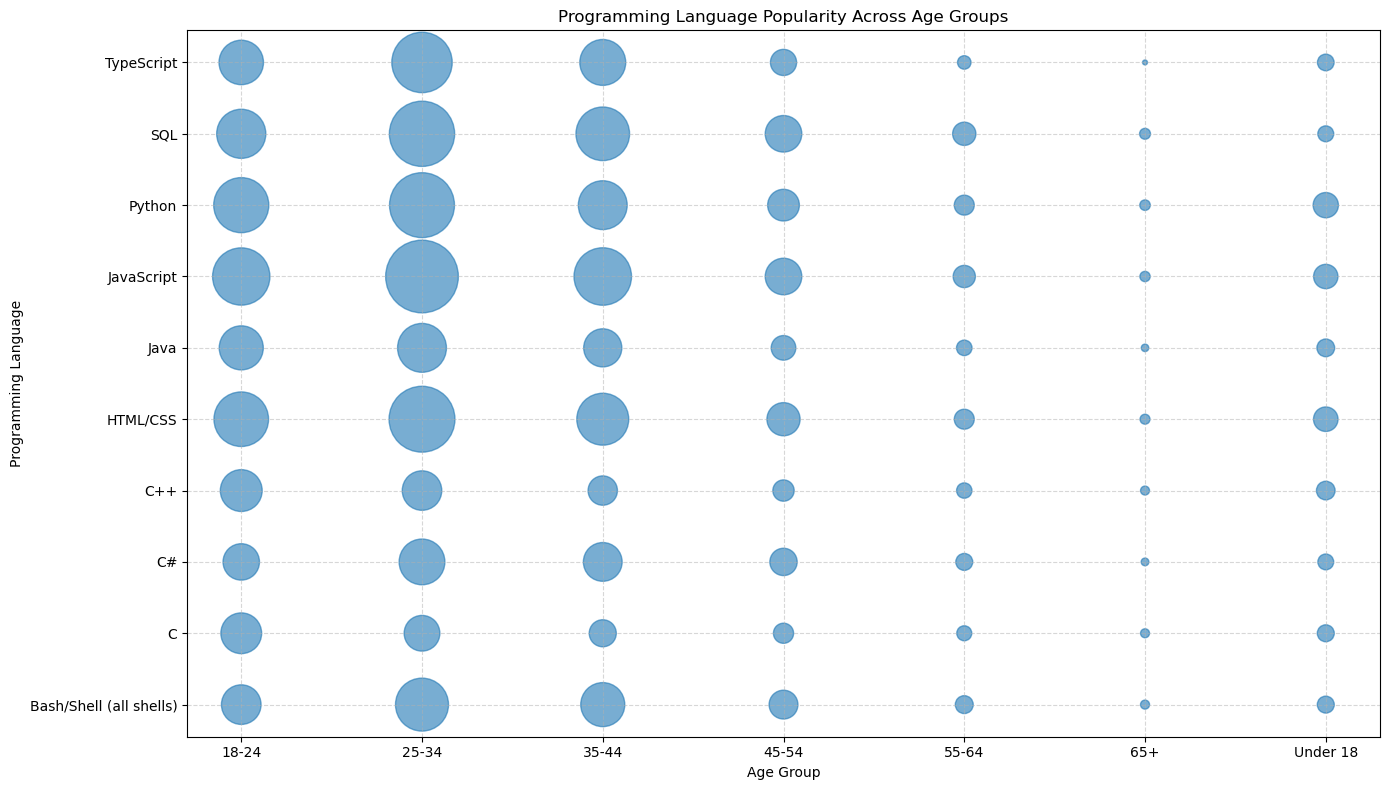

In [21]:
# Create bubble plot

plt.figure(figsize=(14,8))

scatter = plt.scatter(
    language_counts['Age_Group'],
    language_counts['LanguageHaveWorkedWith'],
    s=language_counts['Frequency'] / 5,   # Bubble size
    alpha=0.6
)

plt.title('Programming Language Popularity Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Programming Language')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.

In [22]:
# Select required columns

db_df = df[
    ['DatabaseWantToWorkWith', 'JobSat']
].dropna()

# Display first few rows
print(db_df.head())

                     DatabaseWantToWorkWith  JobSat
10  Elasticsearch;MongoDB;PostgreSQL;SQLite     8.0
12                                    MySQL     8.0
15                     Microsoft SQL Server     5.0
18              Microsoft SQL Server;SQLite    10.0
20    Microsoft SQL Server;MySQL;PostgreSQL     6.0


In [23]:
# Convert JobSat to numeric

db_df['JobSat'] = pd.to_numeric(
    db_df['JobSat'],
    errors='coerce'
)

# Remove missing values
db_df = db_df.dropna()

In [24]:
# Split multiple databases into separate rows

db_exploded = db_df.assign(
    DatabaseWantToWorkWith=
    db_df['DatabaseWantToWorkWith'].str.split(';')
).explode('DatabaseWantToWorkWith')

In [25]:
# Find top 10 preferred databases

top_databases = (
    db_exploded['DatabaseWantToWorkWith']
    .value_counts()
    .head(10)
    .index
)

print(top_databases)

Index(['PostgreSQL', 'SQLite', 'Redis', 'MySQL', 'MongoDB',
       'Microsoft SQL Server', 'Elasticsearch', 'MariaDB', 'Dynamodb',
       'BigQuery'],
      dtype='object', name='DatabaseWantToWorkWith')


In [26]:
# Filter only top databases

filtered_df = db_exploded[
    db_exploded['DatabaseWantToWorkWith'].isin(top_databases)
].copy()

In [27]:
# Calculate average job satisfaction and respondent count

database_stats = (
    filtered_df
    .groupby('DatabaseWantToWorkWith')
    .agg(
        AvgJobSat=('JobSat', 'mean'),
        RespondentCount=('JobSat', 'count')
    )
    .reset_index()
)

print(database_stats)

  DatabaseWantToWorkWith  AvgJobSat  RespondentCount
0               BigQuery   6.947997             1423
1               Dynamodb   7.083256             2150
2          Elasticsearch   6.995094             3873
3                MariaDB   6.989681             3101
4   Microsoft SQL Server   7.065005             4615
5                MongoDB   6.903802             5655
6                  MySQL   6.982421             5973
7             PostgreSQL   6.941633            13261
8                  Redis   6.976072             6436
9                 SQLite   6.923458             6859


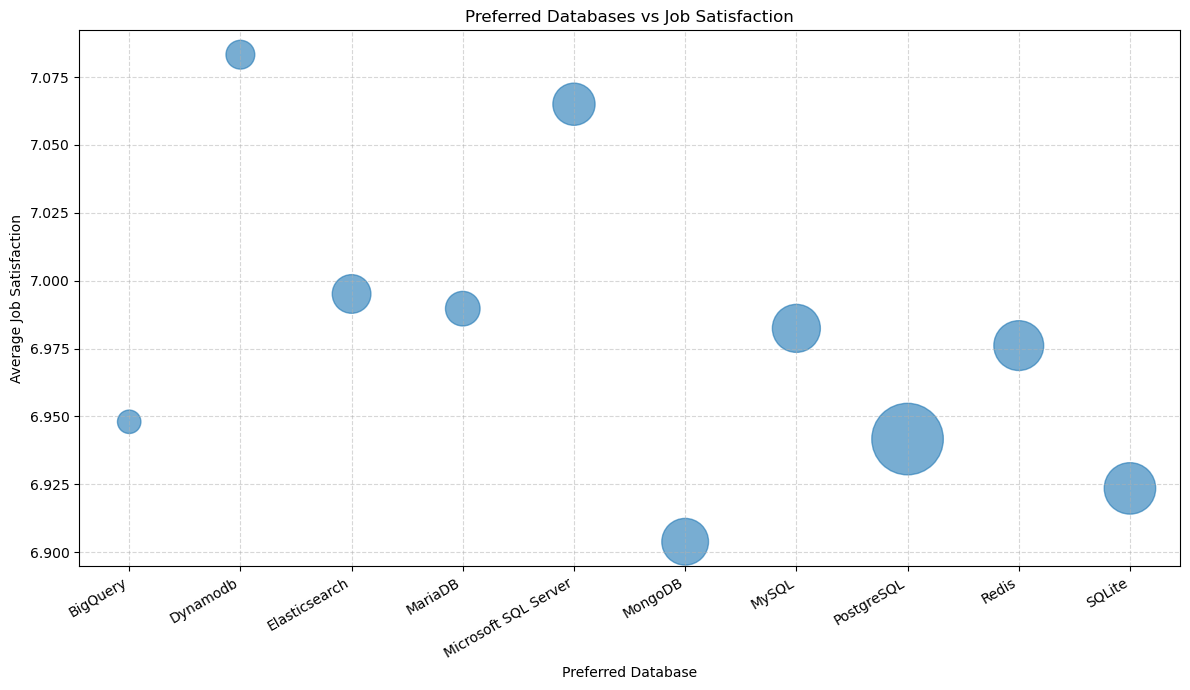

In [28]:
# Create bubble plot

plt.figure(figsize=(12,7))

plt.scatter(
    database_stats['DatabaseWantToWorkWith'],
    database_stats['AvgJobSat'],
    s=database_stats['RespondentCount'] / 5,   # Bubble size
    alpha=0.6
)

plt.title('Preferred Databases vs Job Satisfaction')
plt.xlabel('Preferred Database')
plt.ylabel('Average Job Satisfaction')

plt.xticks(rotation=30, ha='right')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots

#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.

In [29]:
# Select required columns

role_df = df[
    ['DevType', 'ConvertedCompYearly', 'JobSat']
].dropna()

# Display first few rows
print(role_df.head())

                                           DevType  ConvertedCompYearly  \
72   Data scientist or machine learning specialist               7322.0   
379  Data scientist or machine learning specialist              91295.0   
389                                        Student             110000.0   
392                            Engineering manager             161044.0   
398                          Developer, full-stack             195000.0   

     JobSat  
72     10.0  
379    10.0  
389    10.0  
392     7.0  
398     5.0  


In [30]:
# Convert numeric columns

role_df['ConvertedCompYearly'] = pd.to_numeric(
    role_df['ConvertedCompYearly'],
    errors='coerce'
)

role_df['JobSat'] = pd.to_numeric(
    role_df['JobSat'],
    errors='coerce'
)

# Remove missing values
role_df = role_df.dropna()

In [31]:
# Split multiple developer roles into separate rows

role_exploded = role_df.assign(
    DevType=role_df['DevType'].str.split(';')
).explode('DevType')

In [32]:
# Find top 10 developer roles

top_roles = (
    role_exploded['DevType']
    .value_counts()
    .head(10)
    .index
)

print(top_roles)

Index(['Developer, full-stack', 'Developer, back-end', 'Developer, front-end',
       'Developer, desktop or enterprise applications', 'Developer, mobile',
       'Developer, embedded applications or devices',
       'Other (please specify):', 'Engineering manager', 'Data engineer',
       'DevOps specialist'],
      dtype='object', name='DevType')


In [33]:
# Filter top roles

filtered_df = role_exploded[
    role_exploded['DevType'].isin(top_roles)
].copy()

In [34]:
# Remove extreme compensation outliers

upper_limit = filtered_df['ConvertedCompYearly'].quantile(0.99)

filtered_df = filtered_df[
    filtered_df['ConvertedCompYearly'] <= upper_limit
]

In [35]:
# Calculate average compensation and average job satisfaction

role_stats = (
    filtered_df
    .groupby('DevType')
    .agg(
        AvgCompensation=('ConvertedCompYearly', 'mean'),
        AvgJobSat=('JobSat', 'mean')
    )
    .reset_index()
)

print(role_stats)

                                         DevType  AvgCompensation  AvgJobSat
0                                  Data engineer     82135.279898   6.674300
1                              DevOps specialist     79365.120482   6.954819
2                            Developer, back-end     80346.767836   6.889715
3  Developer, desktop or enterprise applications     73110.868383   6.875536
4    Developer, embedded applications or devices     79272.944112   6.848303
5                           Developer, front-end     59978.110383   6.842623
6                          Developer, full-stack     72465.935820   6.900954
7                              Developer, mobile     65745.758865   6.991135
8                            Engineering manager    120729.852217   7.160099
9                        Other (please specify):     96328.495169   7.070048


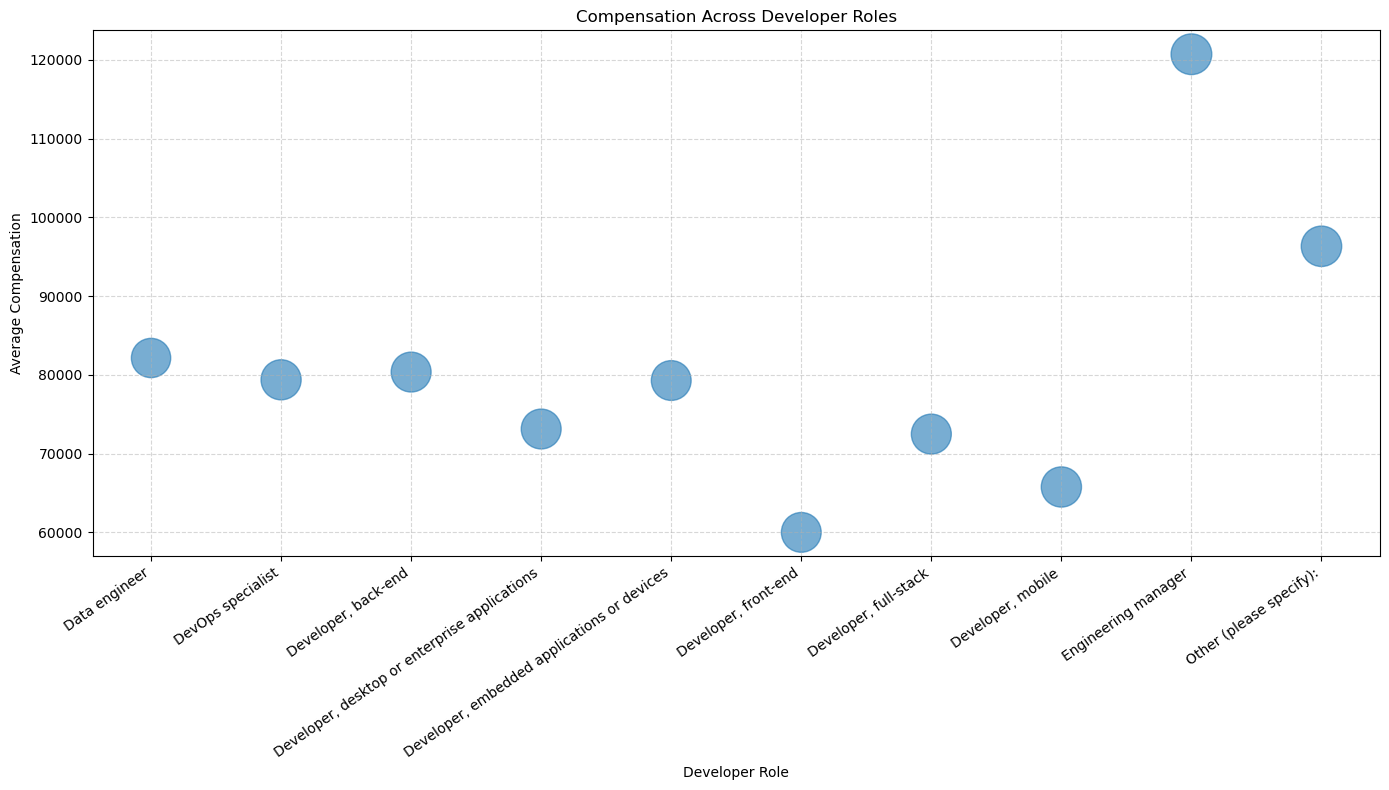

In [37]:
# Create bubble plot

plt.figure(figsize=(14,8))

plt.scatter(
    role_stats['DevType'],
    role_stats['AvgCompensation'],
    s=role_stats['AvgJobSat'] * 120,   # Bubble size based on Job Satisfaction
    alpha=0.6
)

plt.title('Compensation Across Developer Roles')
plt.xlabel('Developer Role')
plt.ylabel('Average Compensation')

plt.xticks(rotation=35, ha='right')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.

In [38]:
# Select required columns

tool_df = df[
    ['Age', 'NEWCollabToolsHaveWorkedWith']
].dropna()

# Display first few rows
print(tool_df.head())

                  Age         NEWCollabToolsHaveWorkedWith
1     35-44 years old  PyCharm;Visual Studio Code;WebStorm
2     45-54 years old                        Visual Studio
4     18-24 years old                                  Vim
5  Under 18 years old    Nano;Vim;Visual Studio Code;Xcode
6     35-44 years old                              RStudio


In [39]:
# Convert Age categories into simplified age groups

age_mapping = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

tool_df['Age_Group'] = (
    tool_df['Age']
    .map(age_mapping)
)

In [40]:
# Split multiple collaboration tools into separate rows

tool_exploded = tool_df.assign(
    NEWCollabToolsHaveWorkedWith=
    tool_df['NEWCollabToolsHaveWorkedWith'].str.split(';')
).explode('NEWCollabToolsHaveWorkedWith')

In [41]:
# Find top 10 collaboration tools

top_tools = (
    tool_exploded['NEWCollabToolsHaveWorkedWith']
    .value_counts()
    .head(10)
    .index
)

print(top_tools)

Index(['Visual Studio Code', 'Visual Studio', 'IntelliJ IDEA', 'Notepad++',
       'Vim', 'Android Studio', 'PyCharm', 'Jupyter Notebook/JupyterLab',
       'Neovim', 'Sublime Text'],
      dtype='object', name='NEWCollabToolsHaveWorkedWith')


In [42]:
# Filter only top collaboration tools

filtered_df = tool_exploded[
    tool_exploded['NEWCollabToolsHaveWorkedWith'].isin(top_tools)
].copy()

In [43]:
# Count frequency of tool usage by age group

tool_counts = (
    filtered_df
    .groupby(['Age_Group', 'NEWCollabToolsHaveWorkedWith'])
    .size()
    .reset_index(name='Frequency')
)

print(tool_counts.head())

  Age_Group NEWCollabToolsHaveWorkedWith  Frequency
0     18-24               Android Studio       2663
1     18-24                IntelliJ IDEA       3932
2     18-24  Jupyter Notebook/JupyterLab       2122
3     18-24                       Neovim       2289
4     18-24                    Notepad++       2368


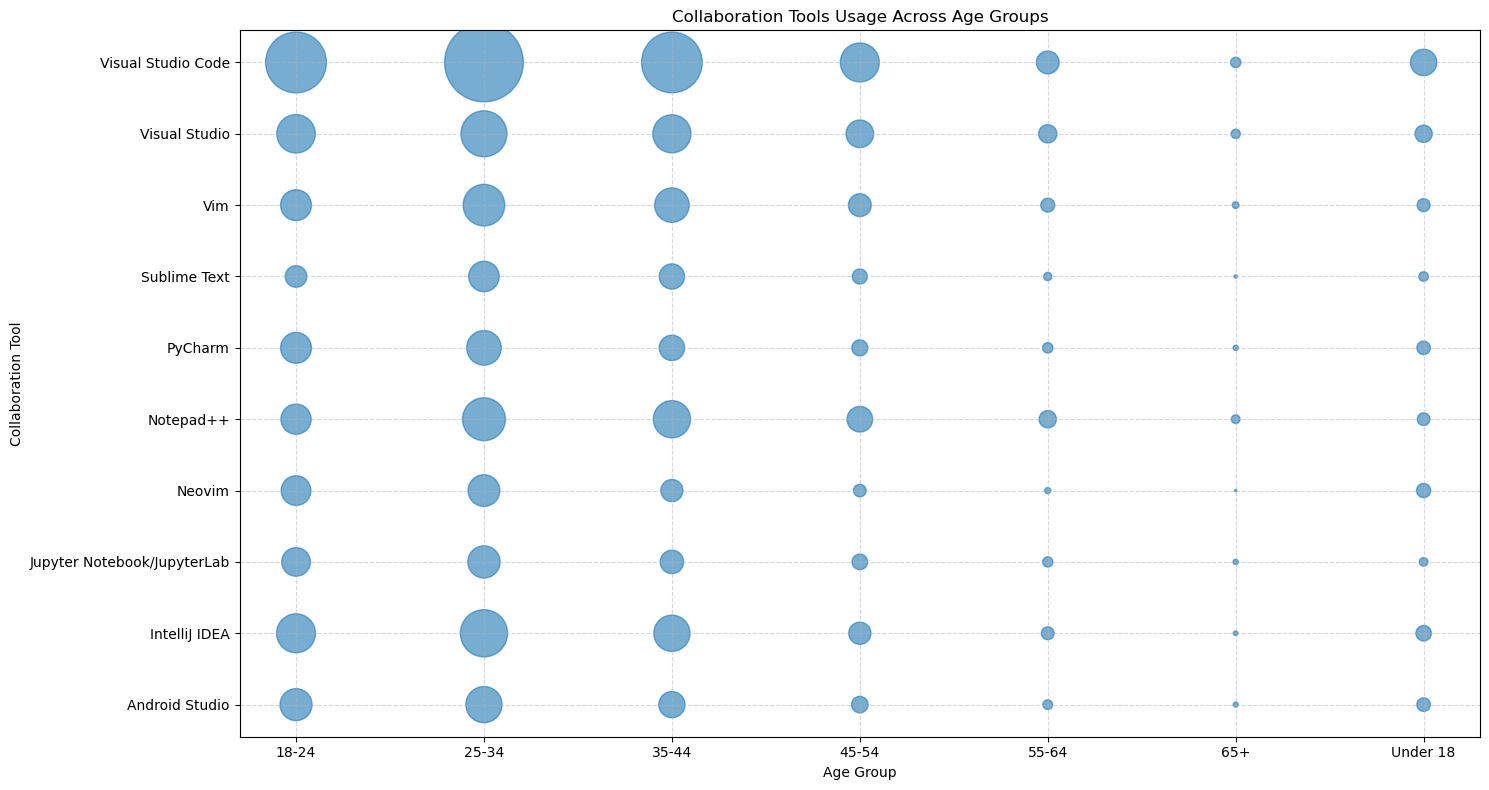

In [44]:
# Create bubble plot

plt.figure(figsize=(15,8))

plt.scatter(
    tool_counts['Age_Group'],
    tool_counts['NEWCollabToolsHaveWorkedWith'],
    s=tool_counts['Frequency'] / 5,   # Bubble size based on frequency
    alpha=0.6
)

plt.title('Collaboration Tools Usage Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots

#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.

In [45]:
# Select required columns

web_df = df[
    ['WebframeWantToWorkWith', 'JobSat']
].dropna()

# Display first few rows
print(web_df.head())

                WebframeWantToWorkWith  JobSat
10  Django;Node.js;React;Ruby on Rails     8.0
15                              Blazor     5.0
18                 ASP.NET CORE;Blazor    10.0
20               Angular;Laravel;React     6.0
22                        ASP.NET CORE     9.0


In [46]:
# Convert JobSat to numeric

web_df['JobSat'] = pd.to_numeric(
    web_df['JobSat'],
    errors='coerce'
)

# Remove missing values
web_df = web_df.dropna()

In [47]:
# Split multiple web frameworks into separate rows

web_exploded = web_df.assign(
    WebframeWantToWorkWith=
    web_df['WebframeWantToWorkWith'].str.split(';')
).explode('WebframeWantToWorkWith')

In [48]:
# Find top 10 preferred web frameworks

top_frameworks = (
    web_exploded['WebframeWantToWorkWith']
    .value_counts()
    .head(10)
    .index
)

print(top_frameworks)

Index(['React', 'Node.js', 'Next.js', 'ASP.NET CORE', 'Vue.js', 'Angular',
       'Spring Boot', 'Express', 'FastAPI', 'Svelte'],
      dtype='object', name='WebframeWantToWorkWith')


In [49]:
# Filter only top frameworks

filtered_df = web_exploded[
    web_exploded['WebframeWantToWorkWith'].isin(top_frameworks)
].copy()

In [50]:
# Calculate average job satisfaction and respondent count

framework_stats = (
    filtered_df
    .groupby('WebframeWantToWorkWith')
    .agg(
        AvgJobSat=('JobSat', 'mean'),
        RespondentCount=('JobSat', 'count')
    )
    .reset_index()
)

print(framework_stats)

  WebframeWantToWorkWith  AvgJobSat  RespondentCount
0           ASP.NET CORE   7.049059             4199
1                Angular   7.009602             3541
2                Express   6.881961             2855
3                FastAPI   6.820212             2731
4                Next.js   6.909070             4322
5                Node.js   7.013227             7636
6                  React   6.951880             8167
7            Spring Boot   6.890136             2940
8                 Svelte   6.791144             2710
9                 Vue.js   6.924895             4061


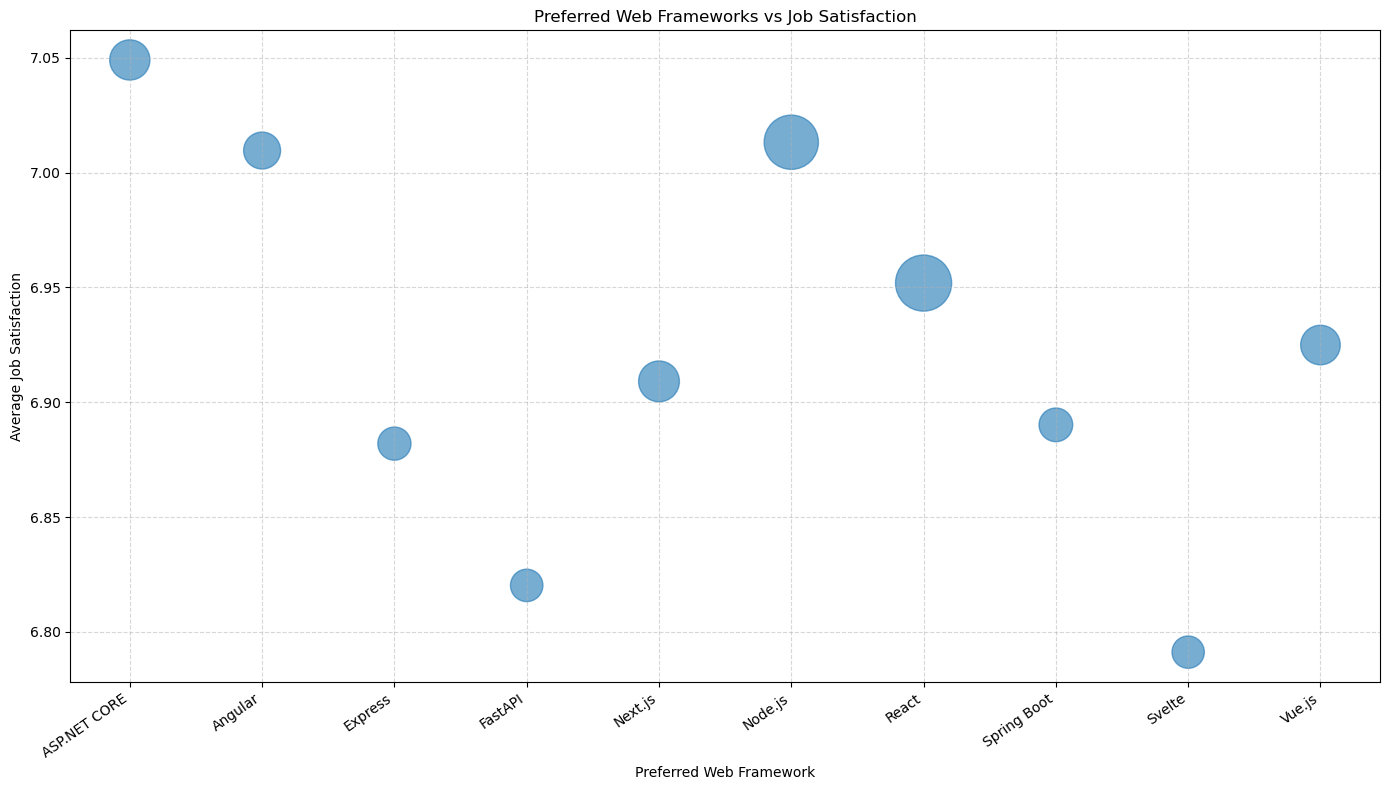

In [51]:
# Create bubble plot

plt.figure(figsize=(14,8))

plt.scatter(
    framework_stats['WebframeWantToWorkWith'],
    framework_stats['AvgJobSat'],
    s=framework_stats['RespondentCount'] / 5,   # Bubble size based on respondents
    alpha=0.6
)

plt.title('Preferred Web Frameworks vs Job Satisfaction')
plt.xlabel('Preferred Web Framework')
plt.ylabel('Average Job Satisfaction')

plt.xticks(rotation=35, ha='right')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.

In [52]:
# Select required columns

admired_df = df[
    ['Country', 'LanguageAdmired']
].dropna()

# Display first few rows
print(admired_df.head())

                                             Country  \
1  United Kingdom of Great Britain and Northern I...   
2  United Kingdom of Great Britain and Northern I...   
3                                             Canada   
4                                             Norway   
5                           United States of America   

                                     LanguageAdmired  
1  Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...  
2                                                 C#  
3  HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...  
4                 C++;HTML/CSS;JavaScript;Lua;Python  
5  Bash/Shell (all shells);HTML/CSS;Java;JavaScri...  


In [53]:
# Split multiple admired technologies into separate rows

admired_exploded = admired_df.assign(
    LanguageAdmired=
    admired_df['LanguageAdmired'].str.split(';')
).explode('LanguageAdmired')

In [54]:
# Find top 10 admired technologies

top_technologies = (
    admired_exploded['LanguageAdmired']
    .value_counts()
    .head(10)
    .index
)

print(top_technologies)

Index(['JavaScript', 'SQL', 'Python', 'HTML/CSS', 'TypeScript',
       'Bash/Shell (all shells)', 'C#', 'Java', 'C++', 'Rust'],
      dtype='object', name='LanguageAdmired')


In [55]:
# Find top 5 countries

top_countries = (
    admired_exploded['Country']
    .value_counts()
    .head(5)
    .index
)

print(top_countries)

Index(['United States of America', 'Germany', 'India',
       'United Kingdom of Great Britain and Northern Ireland', 'France'],
      dtype='object', name='Country')


In [56]:
# Filter top technologies and countries

filtered_df = admired_exploded[
    (admired_exploded['LanguageAdmired'].isin(top_technologies)) &
    (admired_exploded['Country'].isin(top_countries))
].copy()

In [57]:
# Count admiration frequency

admired_counts = (
    filtered_df
    .groupby(['Country', 'LanguageAdmired'])
    .size()
    .reset_index(name='Frequency')
)

print(admired_counts.head())

  Country          LanguageAdmired  Frequency
0  France  Bash/Shell (all shells)        542
1  France                       C#        243
2  France                      C++        315
3  France                 HTML/CSS        712
4  France                     Java        318


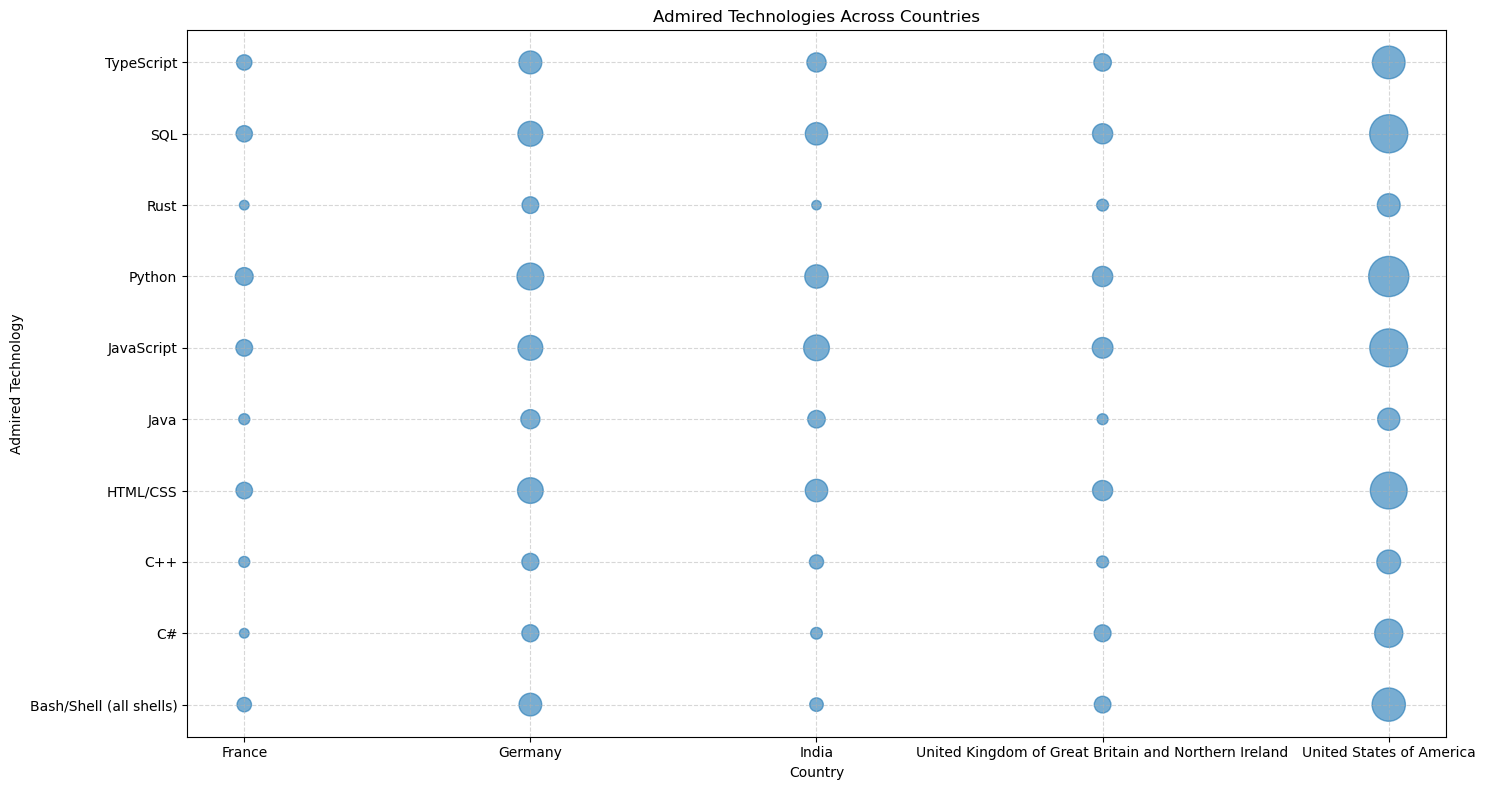

In [58]:
# Create bubble plot

plt.figure(figsize=(15,8))

plt.scatter(
    admired_counts['Country'],
    admired_counts['LanguageAdmired'],
    s=admired_counts['Frequency'] / 5,   # Bubble size based on admiration frequency
    alpha=0.6
)

plt.title('Admired Technologies Across Countries')
plt.xlabel('Country')
plt.ylabel('Admired Technology')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Final Step: Review

After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.

## Summary

After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.